<h1>Gaia Star Cluster Hertzsprung Russel Diagrams (HRD)</h1>

Here are some useful links 
- [European Space Agency Gaia Mission - Writing Queries Turorial](https://www.cosmos.esa.int/web/gaia-users/archive/writing-queries)
- [Gaia's Hertzsprung-Russel Diagram](https://sci.esa.int/web/gaia/-/60198-gaia-hertzsprung-russell-diagram)
- [Measuring the Age of a Star Cluster](https://www.e-education.psu.edu/astro801/content/l7_p6.html#:~:text=The%20HR%20diagram%20for%20stage,%2D13%20billion%20years%20old)

**In the examples below we will query open clusters in the Milky way and plot it in a Hertzsprung-Russel Diagram (HRD). We will also attempt to identify the Main Sequence Cutoff points for these star clusters**

*adapted for the Python for Astronomy Course by Chandru Narayan using the material originally develped by Dr. Priya Hasan and the Gaia utilities*

# Steps to create Hertzsprung-Russel Diagram

- Step 1:  Install the required libraries for astronomy data analysis, querying, and plotting.
- Step 2:  Import the necessary modules from the installed libraries.
- Step 3:  Query the Gaia archive for data within a specified radius around a given cluster.
- Step 4a: Create a Dataframe and Cleanup data as needed.
- Step 4b: Calculate absolute magnitudes and colors from the Gaia data.
- Step 5:  Generate HR diagrams, plotting absolute magnitude against color.
- Repeat Steps 3-5 above for another Star Cluster

## Step 1: Install necessary libraries as necessary

In [1]:
# pip install astropy astroquery matplotlib

## Step 2: Import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia
import astropy.coordinates as coord
import pandas as pd

## Step 3: Query Gaia data

### First perform a Google Search about your target

In [ ]:
### Setup your target here
target_id = 'M67'

In [ ]:
try:
	from googlesearch import search
except ImportError:
	print("No module named 'google' found")

# to search
query = f'{target_id} Wikipedia Astronomy'

for j in search(query, tld="co.in", num=10, stop=10, pause=2):
	print(j)


### Perform your Query

In [ ]:
# Parameters for API Query & HRD (20 minutes radius around Cluster center) - Change for each query!
target = target_id # target to query
object_radius = 1/3 * u.deg # in deg
coordinate = coord.SkyCoord.from_name(target)
print(coordinate)


<SkyCoord (ICRS): (ra, dec) in deg
    (132.846, 11.814)>


In [ ]:
# Define cluster coordinates and radius for Cone search
radius = object_radius
ra = coordinate.ra
dec = coordinate.dec

# Query Gaia
query = f"""
    SELECT source_id, ra, dec, parallax, phot_g_mean_mag, bp_rp
    FROM gaiaedr3.gaia_source 
    WHERE bp_rp > -0.75 AND bp_rp < 4 AND 1=CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra.value}, {dec.value}, {radius.value})
        )
""" 
job = Gaia.launch_job_async(query)
gaia_data = job.get_results()
#print(gaia_data)

INFO: Query finished. [astroquery.utils.tap.core]


## Step 4a: Create a Data Frame & Cleanup Gaia Query Results data

In [ ]:
# Create a DataFrame and Cleanup:
allstars = gaia_data.to_pandas()
print(allstars)
# filter allstars (temp1)
temp1 = allstars.dropna()  # Drop NaN - "not a number"
print(temp1)
# filter parallax > 0 (allstars_filtered) by creating a mask
mask = (allstars.parallax > 1)
allstars_filtered = allstars[mask]
#print(allstars_filtered)
allstars = allstars_filtered.dropna()
#print(allstars)

                source_id          ra        dec  parallax  phot_g_mean_mag  \
0      604625910880696960  133.409667  10.983092       NaN        21.822149   
1      604626082680673920  133.445963  11.008143       NaN        21.120874   
2      604626117039126784  133.399230  10.980871 -0.501336        19.757692   
3      604626121334201984  133.391235  10.987632  0.906051        15.138968   
4      604626151398869248  133.409033  11.001376  0.298192        18.443552   
...                   ...         ...        ...       ...              ...   
19976  601999933516072448  131.905005  12.200895 -1.208950        20.228256   
19977  602000070954870144  131.929875  12.225758 -0.311625        19.691404   
19978  602000070955261184  131.919748  12.223423 -2.436351        20.423265   
19979  602000075250173056  131.924439  12.233467  0.461602        13.469939   
19980  602000075251139456  131.920202  12.221731       NaN        20.412905   

          bp_rp  
0      2.915867  
1      1.392183

## Step 4b: Calculate absolute magnitude and add to DataFrame

### Review Formulas (we drived these in the Star MAgnitudes Module!)
#### The quantity $\boxed{m_{app} - m_{abs}} $ OR $ \boxed {m - M} $ is known as the distance modulus
#### Note that this quantity appears in the equations below to calculate magnitudes and distance
### 1. How to calculate Magnitudes when distance (in pc) is known
#### $$ \boxed{m - M =  5 \times log_{10}(distance) - 5} $$
### 2. How to calculate Magnitudes when parallax (in arc-sec) is known
#### $$ \boxed{m - M =  5 \times log_{10}(1/parallax) - 5} $$
### 3. How to calculate Magnitudes for Gaia calculations when parallax (in milli-arc-sec or 'mas') is known
##### $$ \boxed{m -M = - 5 \times log_{10}(parallax) + 10} $$ OR $$ \boxed{M = m + 5 \times log_{10}(parallax) - 10} $$
#### 4. How to calculate Distance (in pc) when apparent and absolute magnitudes are known
##### $$ \boxed{distance = 10^{\frac{m - M+5}{5}}} $$

In [6]:
# Calculate absolute magnitude with parallax in mas
# Make sure parallax > 0 by creating another filter

distance_modulus = -5 * np.log10(allstars['parallax']) + 10
abs_mag = allstars['phot_g_mean_mag'] - distance_modulus
bp_rp = allstars['bp_rp']

## Step 5: Plot HR diagram

### Simple Plot of HRD

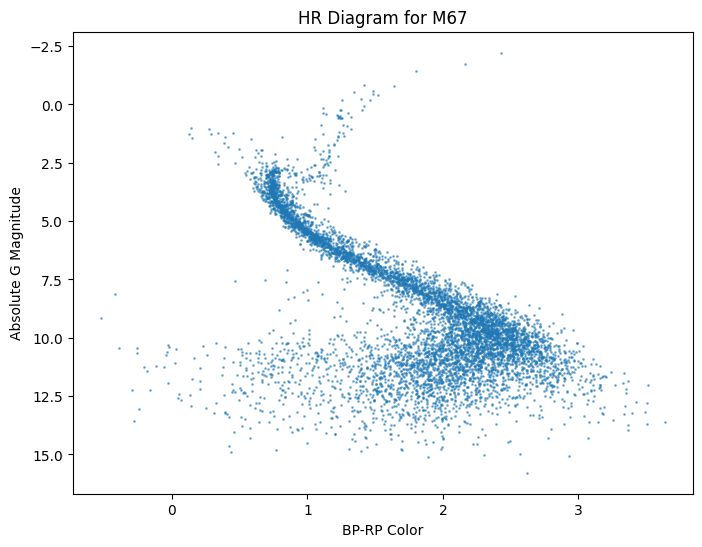

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(bp_rp, abs_mag, s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for {target}")
plt.show()

### Decorated Binned Plot of HRD

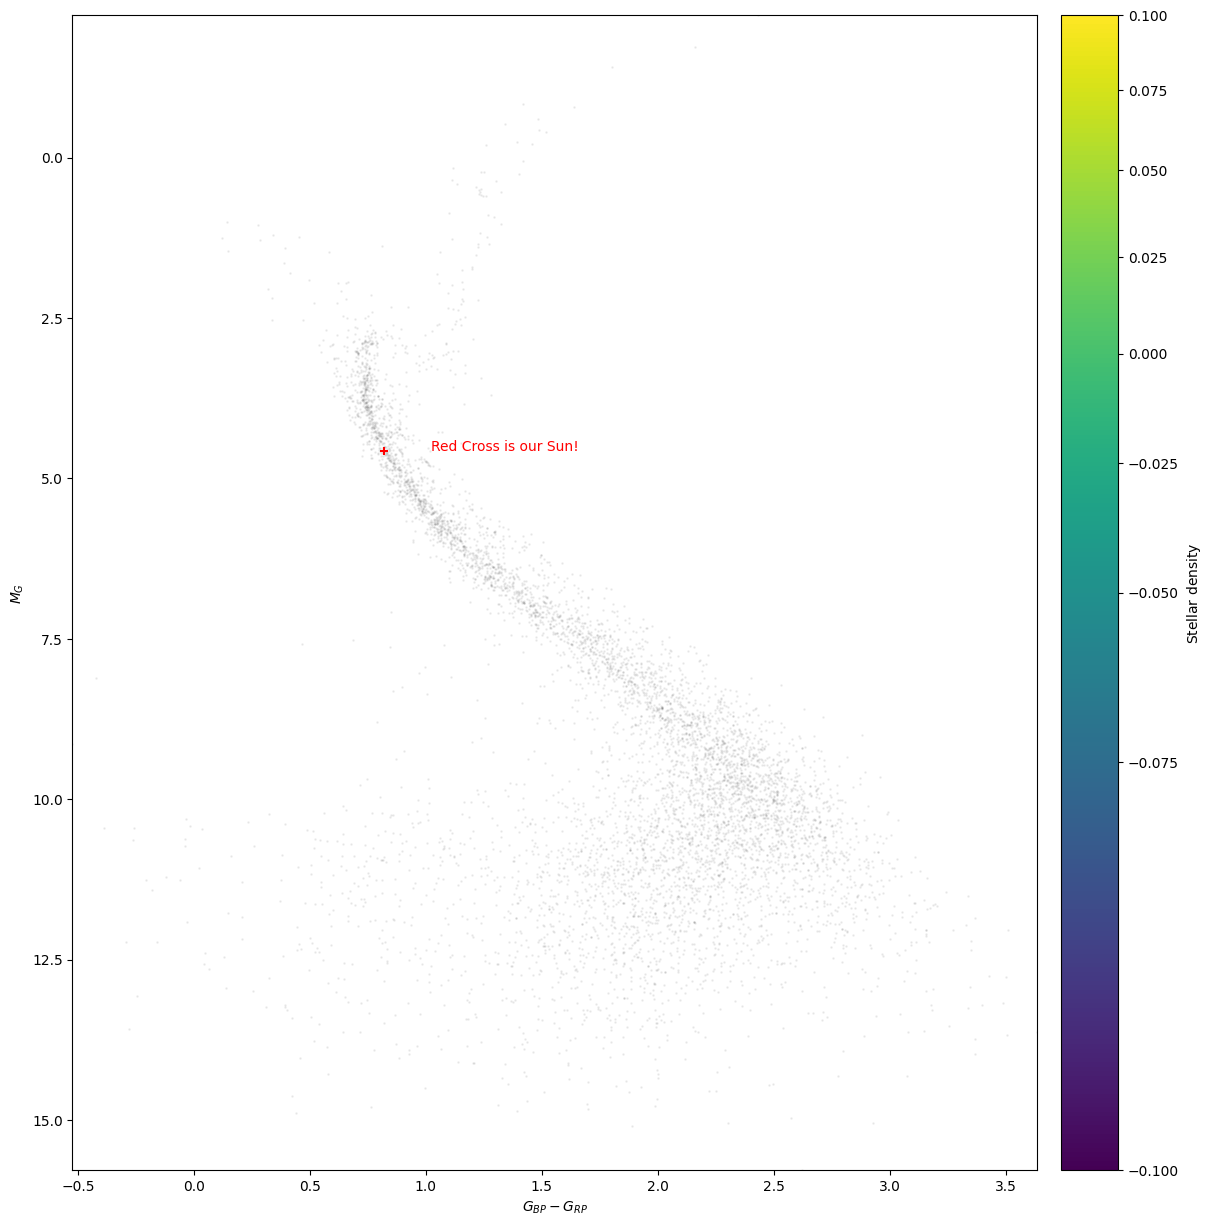

In [8]:
%matplotlib inline
import math
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rc('text', usetex=False)

fig, ax = plt.subplots(figsize=(15, 15))

# sun's HRD coordinates values for plotting
#     google "what is bp-rp of the sun" bp-rp = 0.82
bp_rp_sun = 0.82

#     we calculated the abs mag of the sun in the "brightness of stars" project
#     we will do it again below:
sun_app_mag = -27 # very very bright in the sky!
sun_dist_km = 150e6 #km
light_speed = 3e5 #km/s
seconds_in_a_year = 365*24*60*60
light_year_km =  seconds_in_a_year * light_speed
parsec_km = light_year_km * 3.26 #km/pc
sun_dist_pc = sun_dist_km / parsec_km

# Use the magnitude formula above to calculate the absolute magnitude of the Sun
sun_abs_mag = sun_app_mag - 5 * math.log10(sun_dist_pc) + 5
#print(sun_abs_mag)

# only show 2D-histogram for bins with more than 10 stars in them
ax.scatter(bp_rp_sun, sun_abs_mag, marker='+', color="red") # plot sun
#h = ax.hist2d(bp_rp, mg, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
h = ax.hist2d(bp_rp,abs_mag, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bp_rp,abs_mag, alpha=0.05, s=1, color='k', zorder=0)

plt.text(bp_rp_sun+0.2, sun_abs_mag, "Red Cross is our Sun!",  color="red")
ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.savefig(f"m67.png", dpi=140)
plt.show()

# Repeat Steps 3 to 5 for another Star Cluster

## Step 3: Query Gaia data

### First perform a Google Search about your target

In [ ]:
### Setup your target here
target_id = 'M45'

In [ ]:
try:
	from googlesearch import search
except ImportError:
	print("No module named 'google' found")

# to search
query = f'{target_id} Wikipedia Astronomy'

for j in search(query, tld="co.in", num=10, stop=10, pause=2):
	print(j)


### Perform your Query

In [ ]:
# Parameters for API Query & HRD (20 minutes radius around Cluster center) - Change for each query!
target = target_id # target to query
object_radius = 1/2 * u.deg # in deg
coordinate = coord.SkyCoord.from_name(target)
print(coordinate)


<SkyCoord (ICRS): (ra, dec) in deg
    (132.846, 11.814)>


In [ ]:
# Define cluster coordinates and radius for Cone search
radius = object_radius
ra = coordinate.ra
dec = coordinate.dec

# Query Gaia
query = f"""
    SELECT source_id, ra, dec, parallax, phot_g_mean_mag, bp_rp
    FROM gaiaedr3.gaia_source 
    WHERE bp_rp > -0.75 AND bp_rp < 4 AND 1=CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra.value}, {dec.value}, {radius.value})
        )
""" 
job = Gaia.launch_job_async(query)
gaia_data = job.get_results()
#print(gaia_data)

INFO: Query finished. [astroquery.utils.tap.core]


## Step 4a: Create a Data Frame & Cleanup Gaia Query Results data

In [ ]:
# Create a DataFrame and Cleanup:
allstars = gaia_data.to_pandas()
print(allstars)
# filter allstars (temp1)
temp1 = allstars.dropna()  # Drop NaN - "not a number"
print(temp1)
# filter parallax > 0 (allstars_filtered) by creating a mask
mask = (allstars.parallax > 1)
allstars_filtered = allstars[mask]
#print(allstars_filtered)
allstars = allstars_filtered.dropna()
#print(allstars)

                source_id          ra        dec  parallax  phot_g_mean_mag  \
0      604625910880696960  133.409667  10.983092       NaN        21.822149   
1      604626082680673920  133.445963  11.008143       NaN        21.120874   
2      604626117039126784  133.399230  10.980871 -0.501336        19.757692   
3      604626121334201984  133.391235  10.987632  0.906051        15.138968   
4      604626151398869248  133.409033  11.001376  0.298192        18.443552   
...                   ...         ...        ...       ...              ...   
19976  601999933516072448  131.905005  12.200895 -1.208950        20.228256   
19977  602000070954870144  131.929875  12.225758 -0.311625        19.691404   
19978  602000070955261184  131.919748  12.223423 -2.436351        20.423265   
19979  602000075250173056  131.924439  12.233467  0.461602        13.469939   
19980  602000075251139456  131.920202  12.221731       NaN        20.412905   

          bp_rp  
0      2.915867  
1      1.392183

## Step 4b: Calculate absolute magnitude and add to DataFrame

### Review Formulas (we drived these in the Star MAgnitudes Module!)
#### The quantity $\boxed{m_{app} - m_{abs}} $ OR $ \boxed {m - M} $ is known as the distance modulus
#### Note that this quantity appears in the equations below to calculate magnitudes and distance
### 1. How to calculate Magnitudes when distance (in pc) is known
#### $$ \boxed{m - M =  5 \times log_{10}(distance) - 5} $$
### 2. How to calculate Magnitudes when parallax (in arc-sec) is known
#### $$ \boxed{m - M =  5 \times log_{10}(1/parallax) - 5} $$
### 3. How to calculate Magnitudes for Gaia calculations when parallax (in milli-arc-sec or 'mas') is known
##### $$ \boxed{m -M = - 5 \times log_{10}(parallax) + 10} $$ OR $$ \boxed{M = m + 5 \times log_{10}(parallax) - 10} $$
#### 4. How to calculate Distance (in pc) when apparent and absolute magnitudes are known
##### $$ \boxed{distance = 10^{\frac{m - M+5}{5}}} $$

In [ ]:
# Calculate absolute magnitude with parallax in mas
# Make sure parallax > 0 by creating another filter

distance_modulus = -5 * np.log10(allstars['parallax']) + 10
abs_mag = allstars['phot_g_mean_mag'] - distance_modulus
bp_rp = allstars['bp_rp']

## Step 5: Plot HR diagram

### Simple Plot of HRD

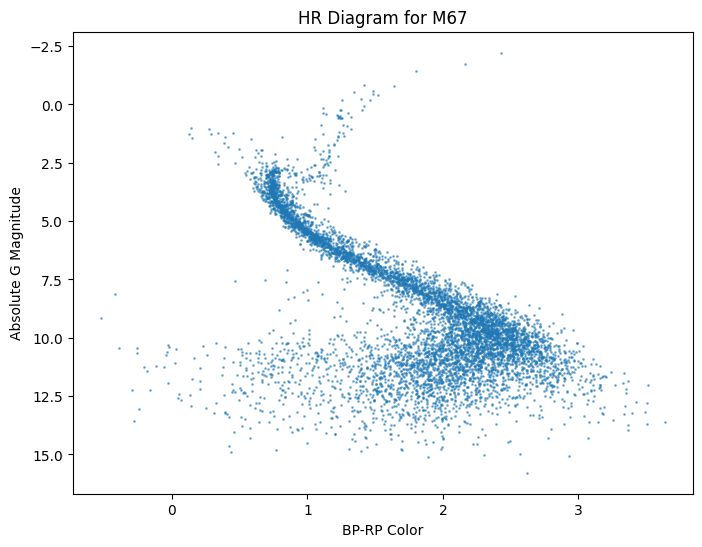

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(bp_rp, abs_mag, s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for {target}")
plt.show()

### Decorated Binned Plot of HRD

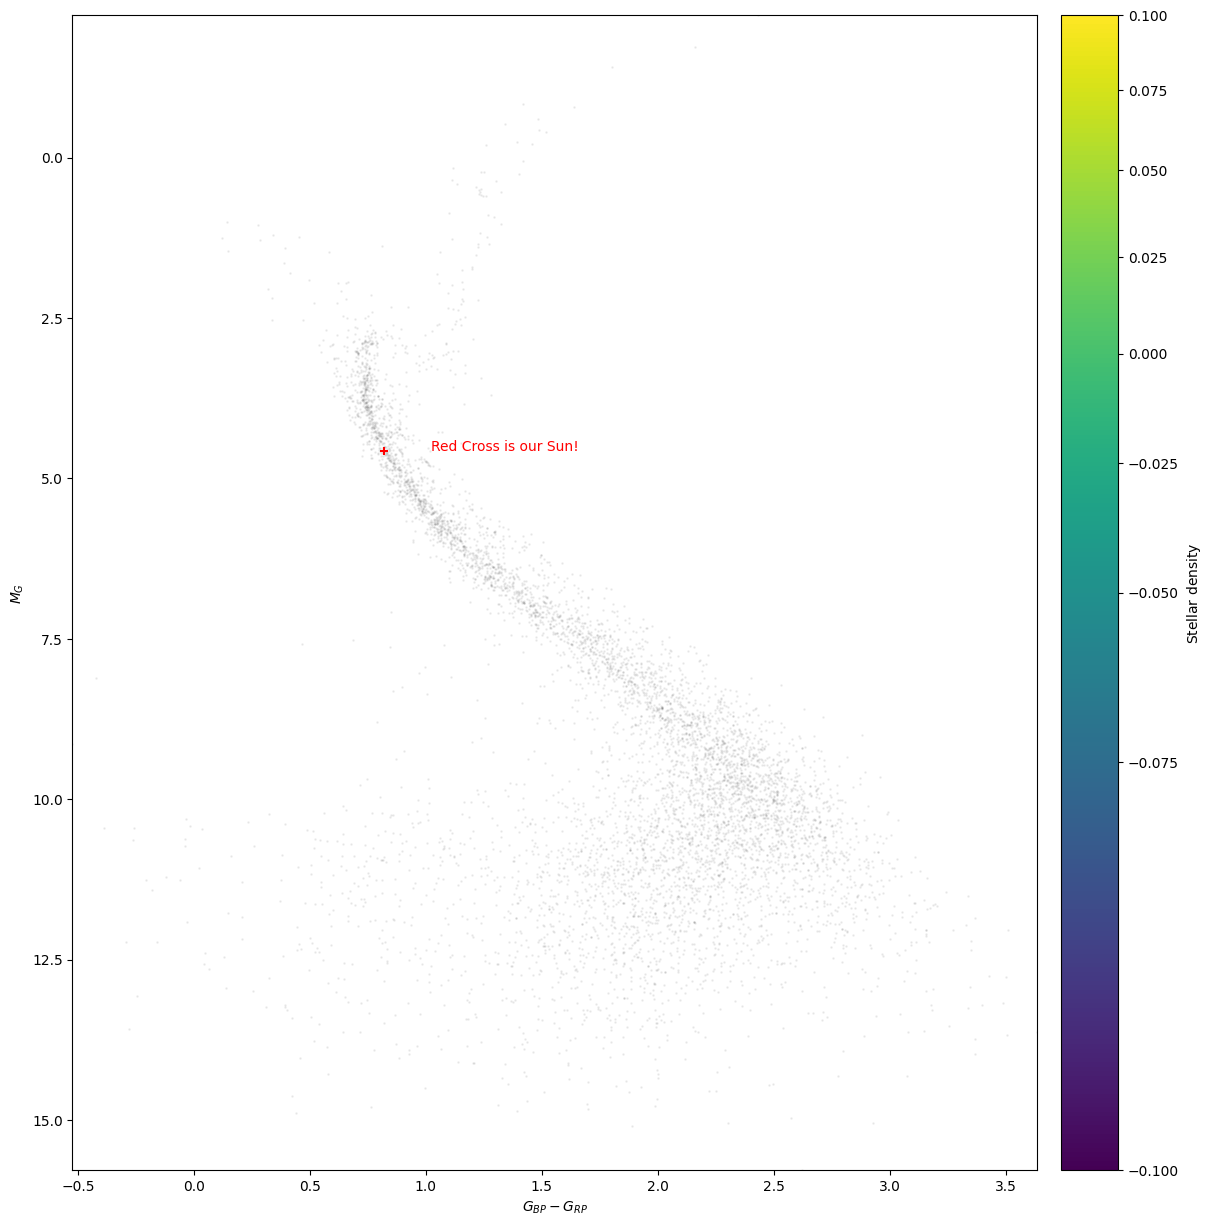

In [ ]:
%matplotlib inline
import math
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rc('text', usetex=False)

fig, ax = plt.subplots(figsize=(15, 15))

# sun's HRD coordinates values for plotting
#     google "what is bp-rp of the sun" bp-rp = 0.82
bp_rp_sun = 0.82

#     we calculated the abs mag of the sun in the "brightness of stars" project
#     we will do it again below:
sun_app_mag = -27 # very very bright in the sky!
sun_dist_km = 150e6 #km
light_speed = 3e5 #km/s
seconds_in_a_year = 365*24*60*60
light_year_km =  seconds_in_a_year * light_speed
parsec_km = light_year_km * 3.26 #km/pc
sun_dist_pc = sun_dist_km / parsec_km

# Use the magnitude formula above to calculate the absolute magnitude of the Sun
sun_abs_mag = sun_app_mag - 5 * math.log10(sun_dist_pc) + 5
#print(sun_abs_mag)

# only show 2D-histogram for bins with more than 10 stars in them
ax.scatter(bp_rp_sun, sun_abs_mag, marker='+', color="red") # plot sun
#h = ax.hist2d(bp_rp, mg, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
h = ax.hist2d(bp_rp,abs_mag, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bp_rp,abs_mag, alpha=0.05, s=1, color='k', zorder=0)

plt.text(bp_rp_sun+0.2, sun_abs_mag, "Red Cross is our Sun!",  color="red")
ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.savefig(f"m67.png", dpi=140)
plt.show()

# Repeat Steps 3 to 5 for another Star Cluster